In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

Solving a Simple Boundary Value Problem

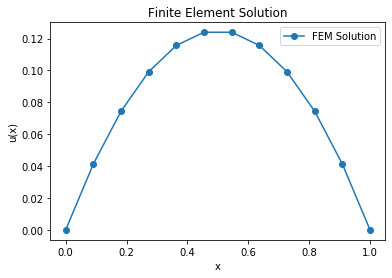

In [21]:
# Problem setup
L = 1 # Length of the domain
N = 10 # Number of elements
h = L / (N + 1) # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)

plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()


Finite Volume Method

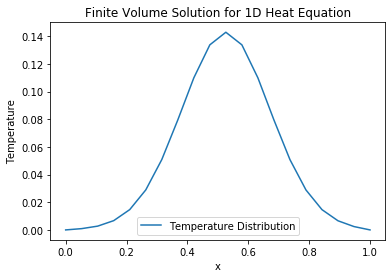

In [29]:
# Parameters
alpha = 0.01 # Diffusion coefficient
dx = 0.05
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx) # Initial temperature distribution
u[int(Nx/2)] = 1.0 # Initial heat at the center

# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 *
        u[i] + u[i - 1])
        
    u = u_new
    
    
# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

Spectral Method

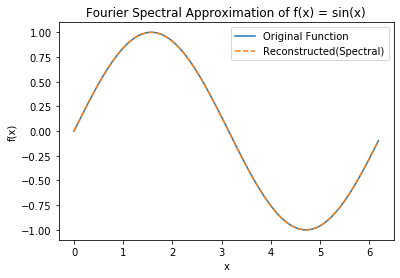

In [34]:
from scipy.fftpack import fft, ifft

# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)

# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real

# Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed(Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()


Forward Euler Method for ODE

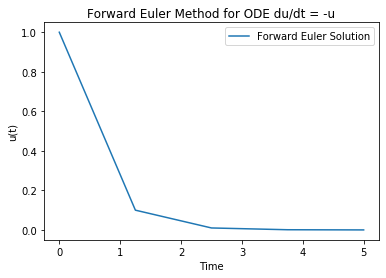

In [40]:
# Define parameters
T = 5.0 # Final time
dt = 0.9 # Time step (smaller it is, )
N = int(T / dt)
u = np.zeros(N)
u[0] = 1 # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]
    
# Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()


# Solving a Simple ODE

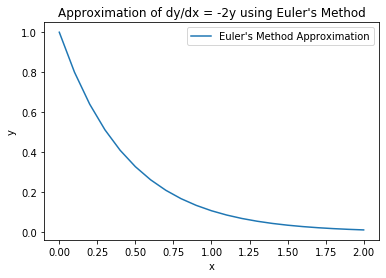

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = 0.1  # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1  # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()